# Multi-class semantic annotation of SpatialData images

This notebook walks through the full workflow for interactively annotating a
multichannel, multiscale SpatialData image and storing the result back into
the same object.

**Steps**
1. Install dependencies & imports
2. Build (or load) a SpatialData object
3. Inspect the image element
4. **Option A** – pixel-level painting with a Labels layer
5. **Option B** – polygon drawing with a Shapes layer
6. Export the annotation back into `sdata`
7. Rasterize shapes → labels (Option B only)
8. Save to Zarr / write individual elements
9. Reload and verify

> **Tip:** Run cells top-to-bottom. The napari window will block execution
> (via `napari.run()`) until you close it.

## 1. Install dependencies

Run once per environment, then restart the kernel.

## 2. Imports

In [1]:
%gui qt

from __future__ import annotations

import numpy as np
import spatialdata

from napari_spatial_data import (
    open_in_napari,
    add_labels_layer,
    add_shapes_layer,
    labels_layer_to_sdata,
    shapes_layer_to_sdata,
    rasterize_shapes_to_labels,
    run_annotation_session,
    get_scale0_xarray,
    get_scale0_shape,
    get_channel_names,
    class_id_colormap,
    print_sdata_summary,
)

c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\spatialdata\_core\query\relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\spatialdata\_core\query\relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = partial(_left_exclusive_join_spatialelement_table)
c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\spatialdata\_core\query\relational_query.py:533: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  inner = partial(_inner_join_spatialelement_table)
c:\Users\

## 3. Build (or load) a SpatialData object

**Option A – demo data (no file needed):** run the cell below to generate a synthetic 4-channel, multiscale image.
```python

def make_demo_sdata(
    height: int = 512, width: int = 512, n_channels: int = 4
) -> spatialdata.SpatialData:
    """Create a toy multichannel, multiscale SpatialData object."""
    rng = np.random.default_rng(42)
    data = rng.integers(0, 2**16, size=(n_channels, height, width), dtype=np.uint16)
    channel_names = ["DAPI", "Marker-A", "Marker-B", "Marker-C"][:n_channels]
    image = Image2DModel.parse(
        data,
        dims=["c", "y", "x"],
        c_coords=channel_names,
        scale_factors=[2, 2],  # full → ½ → ¼ resolution pyramid
    )
    return spatialdata.SpatialData(images={"image": image})


# ----- create / load -----
sdata = make_demo_sdata()
# sdata = spatialdata.read_zarr("path/to/your.zarr")  # ← uncomment to load from disk

print(sdata)
```
**Option B – load from disk:** replace the `make_demo_sdata()` call with  
```python
sdata = spatialdata.read_zarr("path/to/your.zarr")
```

In [2]:
from spatialdata.models import Image2DModel

sdata = spatialdata.read_zarr("//wsl.localhost/Ubuntu-22.04/home/mcowan-wsl/AD_xenium/project_14/test/14w_17825_L1_7_region_001_FOV-01_rotated.zarr")

print(sdata)

C:\Users\mcowan\AppData\Local\Temp\ipykernel_45440\3316179678.py:3: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = spatialdata.read_zarr("//wsl.localhost/Ubuntu-22.04/home/mcowan-wsl/AD_xenium/project_14/test/14w_17825_L1_7_region_001_FOV-01_rotated.zarr")


SpatialData object, with associated Zarr store: \\wsl.localhost\Ubuntu-22.04\home\mcowan-wsl\AD_xenium\project_14\test\14w_17825_L1_7_region_001_FOV-01_rotated.zarr
├── Images
│     └── 'raw': DataTree[cyx] (5, 13740, 24230), (5, 6870, 12115), (5, 3435, 6057), (5, 1717, 3028)
└── Points
      └── 'joint_centroids': DataFrame with shape: (<Delayed>, 3) (2D points)
with coordinate systems:
    ▸ 'global', with elements:
        raw (Images), joint_centroids (Points)


c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\zarr\core\group.py:3535: ZarrUserWarning: Object at zmetadata is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


## 4. Inspect the image element

In [3]:
IMAGE_KEY = "raw"  # change if your image has a different key

h, w = get_scale0_shape(sdata, IMAGE_KEY)
channels = get_channel_names(sdata, IMAGE_KEY)

print(f"Image key  : {IMAGE_KEY!r}")
print(f"Resolution : {h} × {w}  (height × width)")
print(f"Channels   : {channels}")
print()
print_sdata_summary(sdata)

Image key  : 'raw'
Resolution : 13740 × 24230  (height × width)
Channels   : ['0', '1', '2', '3', '4']

SpatialData summary

[images]
  'raw'                          → {'c': 5, 'y': 13740, 'x': 24230}

[points]
  'joint_centroids'              → <class 'dask.dataframe.dask_expr._collection.DataFrame'>


c:\Users\mcowan\Documents\napari_spatial_data\sdata_utils.py:214: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  shape = dict(element["scale0"].ds.dims)  # multiscale


## 5. Option A – Pixel-level painting with a Labels layer

1. Run the cell below – a napari window opens with the image loaded.
2. In napari select the **Labels** layer and choose a label value (integer) in the layer controls panel.
3. Paint regions of interest. Use a different integer for each semantic class:
   - `0` = background (transparent)
   - `1` = class 1
   - `2` = class 2  … and so on.
4. **Close the viewer** when done; the mask is automatically stored in `sdata.labels`.

> Skip this section if you prefer polygon-based annotation (Option B below).

In [8]:
N_CLASSES = 13              # number of semantic classes (excluding background)
LABELS_KEY = "labels_semantic"

# 1: artefact
# 2: epidermis
# 3: dermis
# 4: nail_matrix
# 5: adipose_tissue
# 6: bone
# 7: cartilage
# 8: vascular_structure
# 9: dense_regular_connective_tissue
# 10: muscle
# 11: joint_space
# 12: synovial_cavity
# 13: other

# Open napari, add a blank Labels layer, and block until the window is closed.
run_annotation_session(
    sdata,
    image_key=IMAGE_KEY,
    mode="labels",
    labels_element_name=LABELS_KEY,
    scale_factors=[2, 2],
)

# Quick sanity check
if LABELS_KEY in sdata.labels:
    mask = sdata.labels[LABELS_KEY]
    print(f"\nStored '{LABELS_KEY}' → {mask}")
else:
    print("No labels stored yet (did you close the viewer?)")


[napari] Paint with integer labels:
  background = 0  (unpainted)
  class 1    = 1
  class 2    = 2  … etc.
Close the viewer when done.

No labels stored yet (did you close the viewer?)


## 6. Option B – Polygon drawing with a Shapes layer

1. Run the cell below – napari opens.
2. Select the **Shapes** layer and draw polygons or rectangles around regions of interest.
3. To assign class IDs **before closing**, run (in another cell or the napari console):
   ```python
   # Example: assign class IDs matching the order shapes were drawn
   layer.features["class_id"] = [1, 2, 1, 3, ...]
   ```
   If you skip this step every polygon is assigned class `1`.
4. Close the viewer; polygons are stored in `sdata.shapes` and rasterized to `sdata.labels`.

> Skip this section if you already annotated with Option A.

In [ ]:
SHAPES_KEY = "shapes_semantic"
LABELS_FROM_SHAPES_KEY = "labels_from_shapes"

CLASS_LABELS = {
    1:  "artefact",
    2:  "epidermis",
    3:  "dermis",
    4:  "nail_matrix",
    5:  "adipose_tissue",
    6:  "bone",
    7:  "cartilage",
    8:  "vascular_structure",
    9:  "dense_regular_connective_tissue",
    10: "muscle",
    11: "joint_space",
    12: "synovial_cavity",
    13: "bone_marrow",
    14: "other",
    15: "organelle"
}

run_annotation_session(
    sdata,
    image_key=IMAGE_KEY,
    mode="shapes",
    shapes_element_name=SHAPES_KEY,
    labels_element_name=LABELS_FROM_SHAPES_KEY,
    scale_factors=[2, 2],
    class_labels=CLASS_LABELS,
)

if SHAPES_KEY in sdata.shapes:
    print(f"\nShapes stored ({len(sdata.shapes[SHAPES_KEY])} polygons):")
    print(sdata.shapes[SHAPES_KEY][["class_id", "geometry"]].to_string())
if LABELS_FROM_SHAPES_KEY in sdata.labels:
    print(f"\nRasterized labels '{LABELS_FROM_SHAPES_KEY}':")
    print(sdata.labels[LABELS_FROM_SHAPES_KEY])


[napari] Draw polygons/rectangles on the image.
After each polygon: press T (or click 'Tag last polygon') to
assign the current class ID, then draw the next polygon.
Close the viewer when done.



c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\vispy\geometry\triangulation.py:725: RuntimeWarning: overflow encountered in multiply
  h = (diff * p).sum(axis=-1) / f  # diff dot p / f
c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\vispy\geometry\triangulation.py:720: RuntimeWarning: overflow encountered in multiply
  f = (l2 * p).sum(axis=-1)  # l2 dot p
c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\napari\layers\utils\color_transformations.py:53: UserWarning: The provided face_color parameter has 147 entries, while the data contains 146 entries. Setting face_color to white.
  warnings.warn(


Stored 'shapes_semantic' in sdata.shapes  (n_shapes=259, classes=[1, 2, 3, 5, 6, 8, 9, 10, 12, 14, 15])
Rasterized 'shapes_semantic' → 'labels_from_shapes'  (shape=(13740, 24230), unique classes=[0, 1, 2, 3, 5, 6, 8, 9, 10, 12, 14, 15])


In [6]:
sdata

c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\zarr\core\group.py:3535: ZarrUserWarning: Object at zmetadata is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


SpatialData object, with associated Zarr store: \\wsl.localhost\Ubuntu-22.04\home\mcowan-wsl\AD_xenium\project_14\test\14w_17825_L1_7_region_001_FOV-01_rotated.zarr
├── Images
│     └── 'raw': DataTree[cyx] (5, 13740, 24230), (5, 6870, 12115), (5, 3435, 6057), (5, 1717, 3028)
├── Labels
│     └── 'labels_from_shapes': DataTree[yx] (13740, 24230), (6870, 12115), (3435, 6057)
├── Points
│     └── 'joint_centroids': DataFrame with shape: (<Delayed>, 3) (2D points)
└── Shapes
      └── 'shapes_semantic': GeoDataFrame shape: (259, 2) (2D shapes)
with coordinate systems:
    ▸ 'global', with elements:
        raw (Images), labels_from_shapes (Labels), joint_centroids (Points), shapes_semantic (Shapes)
with the following elements not in the Zarr store:
    ▸ shapes_semantic (Shapes)
    ▸ labels_from_shapes (Labels)

## 7. Programmatic (headless) annotation

Use this section in automated pipelines or CI where no display is available.  
It creates a synthetic 3-class mask without opening napari.

In [ ]:
import napari

PROG_LABELS_KEY = "labels_programmatic"

h, w = get_scale0_shape(sdata, IMAGE_KEY)

# Build a synthetic 3-class mask
mask = np.zeros((h, w), dtype=np.int32)
mask[: h // 3, :] = 1           # top third  → class 1
mask[h // 3 : 2 * h // 3, :] = 2  # middle third → class 2
mask[2 * h // 3 :, :] = 3       # bottom third → class 3

# Wrap it in a headless napari viewer so we can use labels_layer_to_sdata
viewer = napari.Viewer(show=False)
labels_layer = viewer.add_labels(mask, name=PROG_LABELS_KEY)

labels_layer_to_sdata(
    labels_layer,
    sdata,
    image_key=IMAGE_KEY,
    element_name=PROG_LABELS_KEY,
    scale_factors=[2, 2],
)
viewer.close()

print(sdata.labels[PROG_LABELS_KEY])

## 8. Rasterize Shapes → Labels (Option B post-processing)

If you used Option B and want a raster version of the shapes *with* class IDs burned in,
run the cell below.  This step is performed automatically by `run_annotation_session` in
shapes mode, but you can re-run it any time (e.g. after editing `class_id` values).

In [10]:
import rasterio

# Only run if you used Option B (shapes annotation)
if SHAPES_KEY in sdata.shapes:
    rasterize_shapes_to_labels(
        sdata,
        shapes_key=SHAPES_KEY,
        image_key=IMAGE_KEY,
        element_name=LABELS_FROM_SHAPES_KEY,
        class_column="class_id",
        scale_factors=[2, 2, 2],
    )
    print(sdata.labels[LABELS_FROM_SHAPES_KEY])
else:
    print(f"No shapes found under key '{SHAPES_KEY}'. Run Option B first.")

Rasterized 'shapes_semantic' → 'labels_from_shapes'  (shape=(13740, 24230), unique classes=[0, 1, 2, 3, 5, 6, 8, 9, 10, 12, 14, 15])
<xarray.DataTree>
Group: /
├── Group: /scale0
│       Dimensions:  (y: 13740, x: 24230)
│       Coordinates:
│         * y        (y) float64 110kB 0.5 1.5 2.5 3.5 ... 1.374e+04 1.374e+04 1.374e+04
│         * x        (x) float64 194kB 0.5 1.5 2.5 3.5 ... 2.423e+04 2.423e+04 2.423e+04
│       Data variables:
│           image    (y, x) int32 1GB dask.array<chunksize=(256, 256), meta=np.ndarray>
├── Group: /scale1
│       Dimensions:  (y: 6870, x: 12115)
│       Coordinates:
│         * y        (y) float64 55kB 1.0 3.0 5.0 7.0 ... 1.374e+04 1.374e+04 1.374e+04
│         * x        (x) float64 97kB 1.0 3.0 5.0 7.0 ... 2.422e+04 2.423e+04 2.423e+04
│       Data variables:
│           image    (y, x) int32 333MB dask.array<chunksize=(256, 256), meta=np.ndarray>
├── Group: /scale2
│       Dimensions:  (y: 3435, x: 6057)
│       Coordinates:
│         * y    

In [11]:
sdata

c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\zarr\core\group.py:3535: ZarrUserWarning: Object at zmetadata is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


SpatialData object, with associated Zarr store: \\wsl.localhost\Ubuntu-22.04\home\mcowan-wsl\AD_xenium\project_14\test\14w_17825_L1_7_region_001_FOV-01_rotated.zarr
├── Images
│     └── 'raw': DataTree[cyx] (5, 13740, 24230), (5, 6870, 12115), (5, 3435, 6057), (5, 1717, 3028)
├── Labels
│     └── 'labels_from_shapes': DataTree[yx] (13740, 24230), (6870, 12115), (3435, 6057), (1717, 3028)
├── Points
│     └── 'joint_centroids': DataFrame with shape: (<Delayed>, 3) (2D points)
└── Shapes
      └── 'shapes_semantic': GeoDataFrame shape: (259, 2) (2D shapes)
with coordinate systems:
    ▸ 'global', with elements:
        raw (Images), labels_from_shapes (Labels), joint_centroids (Points), shapes_semantic (Shapes)
with the following elements not in the Zarr store:
    ▸ shapes_semantic (Shapes)
    ▸ labels_from_shapes (Labels)

INFO     Rasterizing image for faster rendering.                                                                   
INFO     Your image has 5 channels. Sampling categorical colors and using multichannel strategy 'stack' to render. 
INFO     Rasterizing image for faster rendering.                                                                   


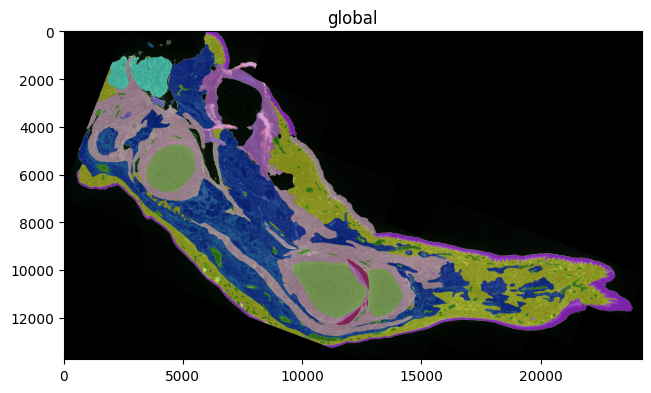

In [12]:
import spatialdata_plot

sdata.pl.render_images("raw").pl.render_labels("labels_from_shapes").pl.show()

## 9. Save to Zarr / write individual elements

`sdata.write()` persists the entire SpatialData object (images, labels, shapes, …)
to a single Zarr store on disk.  Use `overwrite=True` to replace an existing store.

In [ ]:
ZARR_PATH = "annotated.zarr"   # change to your desired output path

sdata.write(ZARR_PATH, overwrite=False)
print(f"Saved → {ZARR_PATH!r}")

c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\ome_zarr\writer.py:319: FutureWarning: Passing storage-related arguments via **kwargs is deprecated. Please use the 'zarr_store_kwargs' parameter instead. **kwargs will be removed in a future version.
  da_delayed = da.to_zarr(


Saved → 'annotated.zarr'


## 10. Reload and verify

Reload from disk and confirm all elements round-trip correctly.

In [15]:
reloaded_sdata = spatialdata.read_zarr(ZARR_PATH)
print(f"Reloaded from {ZARR_PATH!r}\n")
print(reloaded_sdata)

Reloaded from 'annotated.zarr'

SpatialData object, with associated Zarr store: C:\Users\mcowan\Documents\napari_spatial_data\annotated.zarr
├── Images
│     └── 'raw': DataTree[cyx] (5, 13740, 24230), (5, 6870, 12115), (5, 3435, 6057), (5, 1717, 3028)
├── Labels
│     └── 'labels_from_shapes': DataTree[yx] (13740, 24230), (6870, 12115), (3435, 6057), (1717, 3028)
├── Points
│     └── 'joint_centroids': DataFrame with shape: (<Delayed>, 3) (2D points)
└── Shapes
      └── 'shapes_semantic': GeoDataFrame shape: (259, 2) (2D shapes)
with coordinate systems:
    ▸ 'global', with elements:
        raw (Images), labels_from_shapes (Labels), joint_centroids (Points), shapes_semantic (Shapes)


In [16]:
print(reloaded_sdata["shapes_semantic"])

     class_id                                           geometry
0           9  POLYGON ((2869.189 1895.386, 3112.655 2288.678...
1           9  POLYGON ((2880.283 1127.234, 2755.307 1315.795...
2          10  POLYGON ((2522.2 1047.322, 2610.992 1106.516, ...
3          10  POLYGON ((3417.89 1086.483, 3585.263 1073.269,...
4           3  POLYGON ((1405.853 2959.782, 1592.31 2919.383,...
..        ...                                                ...
254        15  POLYGON ((20848.086 9906.077, 20803.906 9911.2...
255        15  POLYGON ((21169.039 9939.861, 21143.051 9956.7...
256        15  POLYGON ((19538.861 9638.705, 19504.828 9655.7...
257        15  POLYGON ((19945.713 9654.175, 19913.227 9675.8...
258        15  POLYGON ((18491.361 9739.132, 18467.35 9770.78...

[259 rows x 2 columns]


## Tips & next steps

| Goal | How |
|---|---|
| Change brush size in napari | `Labels` layer → scroll-wheel or the *Brush size* slider |
| Review annotations with a custom colormap | Call `class_id_colormap(n_classes=3)` and pass the result to `viewer.add_labels(..., color=colormap)` |
| Export only one element | `sdata.write_element("labels_semantic")` after the store is created |
| Work with real data | Replace `make_demo_sdata()` with `spatialdata.read_zarr(...)` |
| Add a cell-segmentation table | Attach an `AnnData` table via `sdata.tables["cells"] = ...` |